# Real Estate Investment Analysis: California Housing Market
## 1. Problem Definition
The objective of this analysis is to identify the key drivers of real estate prices in California. The intended audience is a **Real Estate Investment Trust (REIT)** looking to optimize their acquisition strategy by understanding how location, income, and housing features affect property valuation. [cite_start]This directly addresses a business-related context[cite: 36].

## 2. Data Source
* **Source:** California Housing Dataset (originally from the StatLib repository, fetched via a stable direct URL).
* **Access Date:** April 2026.
* **Method:** Data is loaded directly via URL to ensure seamless reproducibility without requiring local CSV downloads.

In [35]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load data directly from a stable URL to avoid local path issues
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
print("Loading data from URL...")
df = pd.read_csv(url)

# Display the first few rows of the dataset
display(df.head())

Loading data from URL...


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Data Cleaning and Preparation
Before analysis, we must handle missing values and prepare the data.

In [36]:
# Check for missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Fill missing 'total_bedrooms' with the median value (robust to outliers)
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

# Create a new feature: 'rooms_per_household' to provide better business insight
df['rooms_per_household'] = df['total_rooms'] / df['households']

print("\nMissing values after cleaning:\n", df.isnull().sum())
print(f"\nDataset shape: {df.shape}")

Missing values before cleaning:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Missing values after cleaning:
 longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms         0
population             0
households             0
median_income          0
median_house_value     0
ocean_proximity        0
rooms_per_household    0
dtype: int64

Dataset shape: (20640, 11)


## 4. Substantive Analysis and Visualizations
We will explore the data using five distinct visualizations to extract business insights.

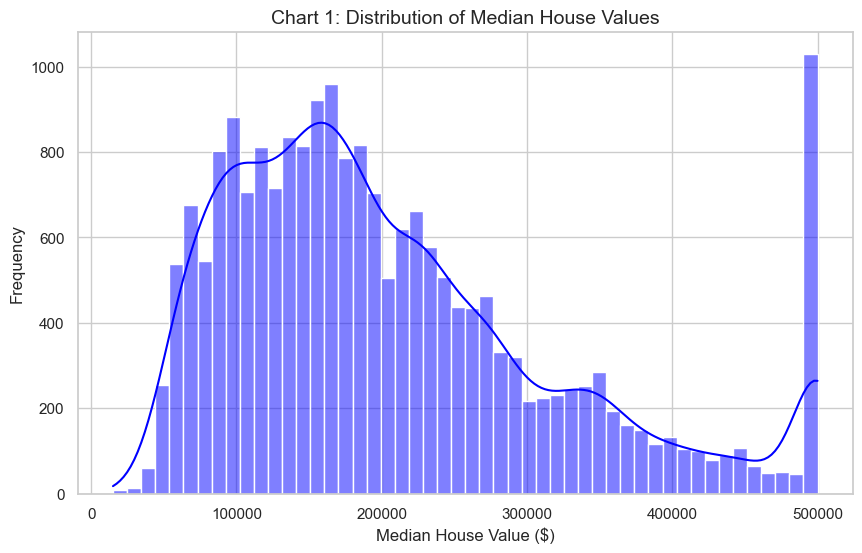

In [37]:
# Chart 1: Distribution of Median House Values (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='blue')
plt.title('Chart 1: Distribution of Median House Values', fontsize=14)
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.show()

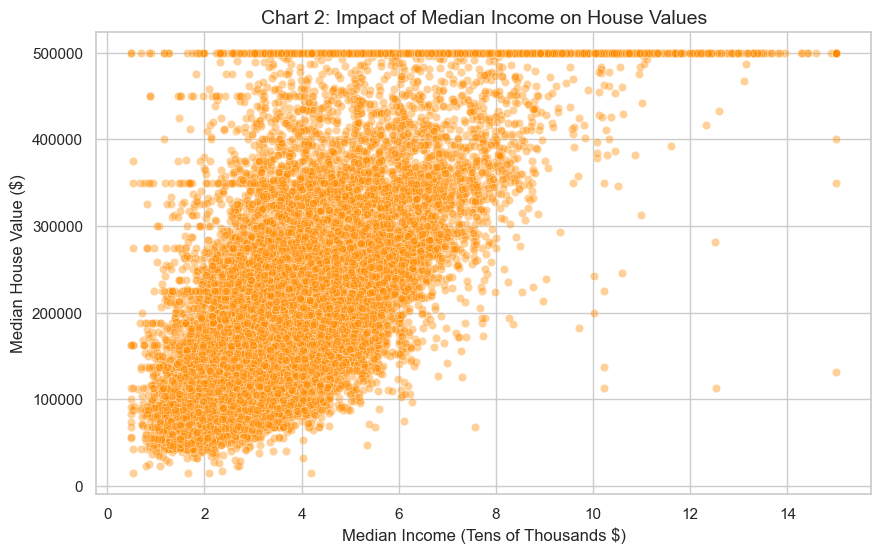

In [38]:
# Chart 2: Median Income vs. Median House Value (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.4, color='darkorange')
plt.title('Chart 2: Impact of Median Income on House Values', fontsize=14)
plt.xlabel('Median Income (Tens of Thousands $)')
plt.ylabel('Median House Value ($)')
plt.show()

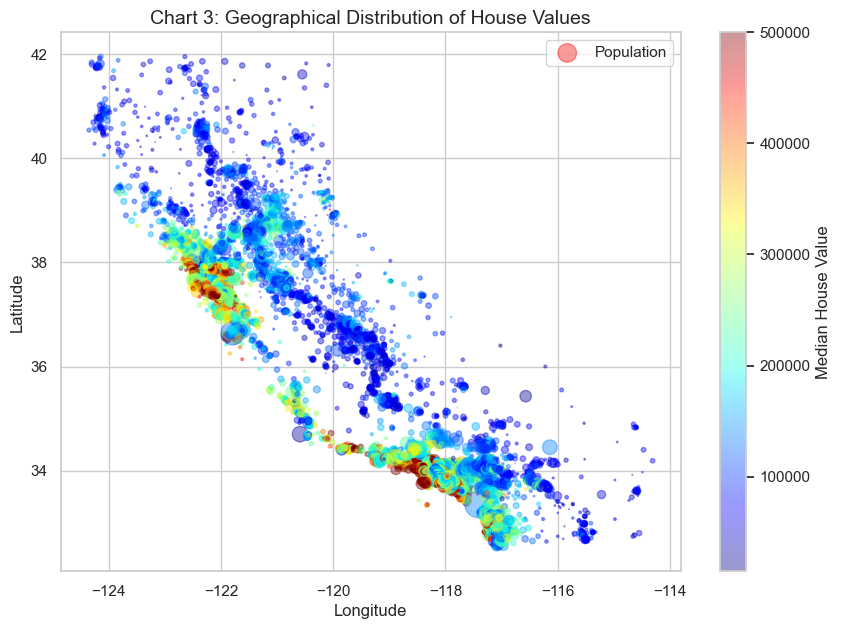

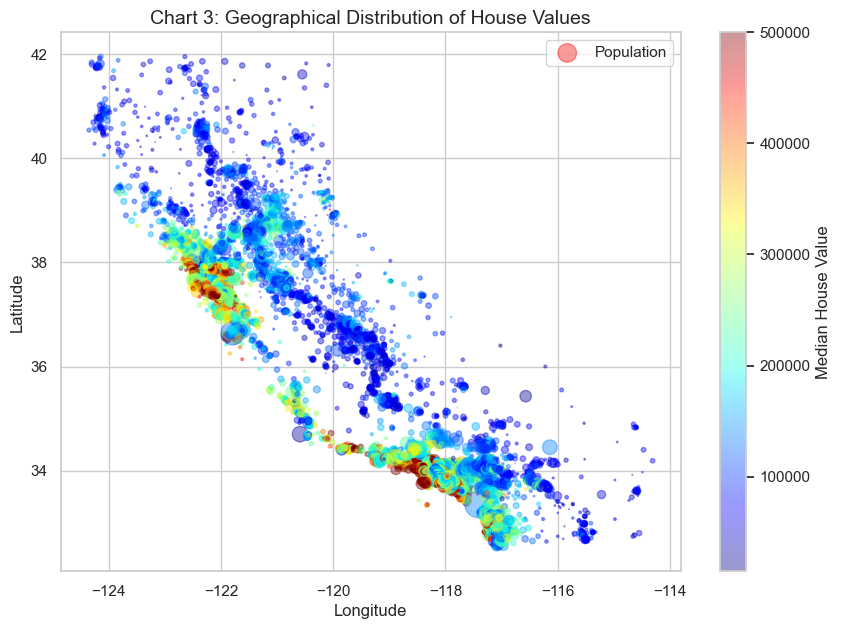

In [39]:
# Chart 3: Geographical Mapping of Prices (Scatter Plot with Hue)
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['longitude'], df['latitude'], alpha=0.4, 
                 s=df['population']/100, label='Population', 
                 c=df['median_house_value'], cmap=plt.get_cmap('jet'))
plt.colorbar(sc, label='Median House Value')
plt.title('Chart 3: Geographical Distribution of House Values', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()# Chart 3: Geographical Mapping of Prices (Scatter Plot with Hue)
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['longitude'], df['latitude'], alpha=0.4, 
                 s=df['population']/100, label='Population', 
                 c=df['median_house_value'], cmap=plt.get_cmap('jet'))
plt.colorbar(sc, label='Median House Value')
plt.title('Chart 3: Geographical Distribution of House Values', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

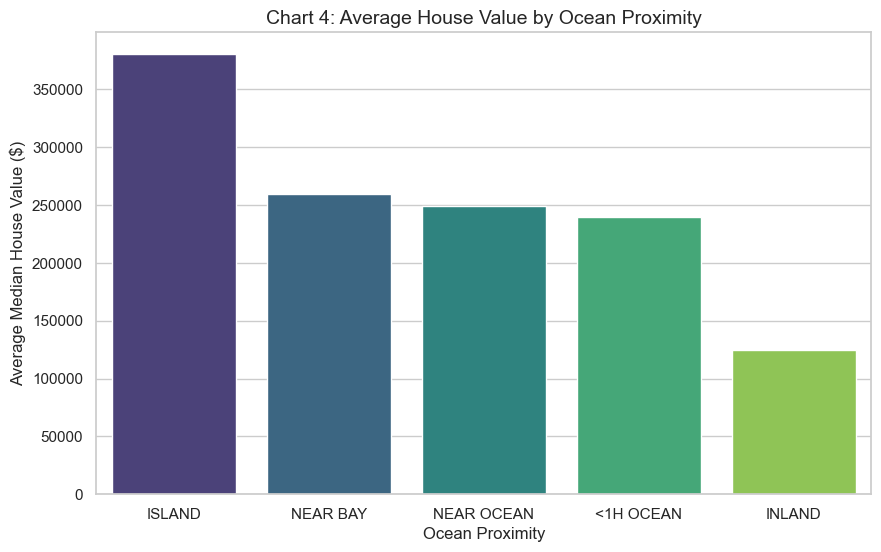

In [44]:
# Chart 4: Average House Value by Ocean Proximity (Bar Chart)
plt.figure(figsize=(10, 6))
ocean_avg = df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False)

# 修复了 FutureWarning: 添加了 hue 参数并设置 legend=False
sns.barplot(x=ocean_avg.index, y=ocean_avg.values, hue=ocean_avg.index, palette='viridis', legend=False)

plt.title('Chart 4: Average House Value by Ocean Proximity', fontsize=14)
plt.xlabel('Ocean Proximity')
plt.ylabel('Average Median House Value ($)')
plt.show()

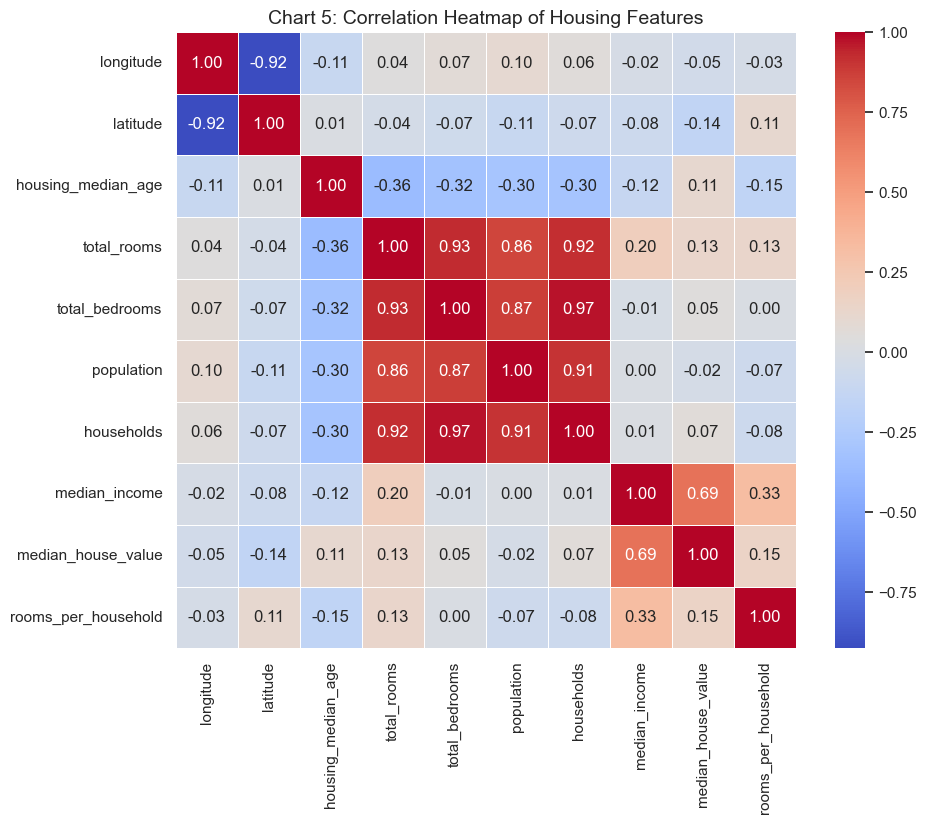

In [41]:
# Chart 5: Correlation Heatmap (excluding non-numeric column)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Chart 5: Correlation Heatmap of Housing Features', fontsize=14)
plt.show()

## 5. Key Findings
1. **Income is King:** Median income has the strongest positive correlation (0.69) with housing values.
2. **Location Premium:** Properties located 'Island' or 'Near Bay' command a significant price premium compared to inland properties.
3. **Coastal Clusters:** The geographical scatter plot clearly shows that highest value homes are clustered tightly along the coastline (Los Angeles and Bay Area).